# PageRank Implementation with Sparse Matrices, Personalized PageRank, and Kernel Extensions

This notebook implements PageRank using sparse linear algebra and connects the code directly to the mathematical formulation used in the report.

The core PageRank equation is

$$
\pi = \alpha P^T \pi + (1-\alpha)v,
$$

where $P$ is the row-stochastic transition matrix, $P^T$ propagates rank into nodes under the column-vector convention, $\alpha$ is the damping factor, and $v$ is the teleportation distribution.

The implementation uses a sparse matrix representation, so each power-iteration step costs $O(|E|)$ rather than $O(n^2)$.


In [3]:
import numpy as np
import scipy.sparse as sp
import time
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
print("Libraries loaded")


Libraries loaded


## 1. Parameters

We use a large random directed graph for the main scalability experiment, and a smaller preferential-attachment graph for a more structured graph-learning example.


In [4]:
# Main experiment parameters
N_NODES  = 10_000
N_EDGES  = 1_000_000
DAMPING  = 0.85
MAX_ITER = 100
TOL      = 1e-6
SEED     = 42

rng = np.random.default_rng(SEED)


## 2. Graph Generation

The first graph is a large random directed graph. It is useful for demonstrating sparse computation at scale.

The second graph is a preferential-attachment graph. It is more realistic for PageRank because it produces hub-like nodes, which resemble the heavy-tailed structure often observed in web and citation networks.


In [5]:
def generate_random_directed_graph(n_nodes, n_edges, seed=42):
    """Generate a deduplicated random directed graph without self-loops."""
    rng = np.random.default_rng(seed)
    src = rng.integers(0, n_nodes, size=n_edges)
    dst = rng.integers(0, n_nodes, size=n_edges)

    mask = src != dst
    src, dst = src[mask], dst[mask]

    packed = src.astype(np.int64) * n_nodes + dst.astype(np.int64)
    packed = np.unique(packed)

    src = (packed // n_nodes).astype(np.int32)
    dst = (packed % n_nodes).astype(np.int32)
    return src, dst


def generate_preferential_attachment_graph(n_nodes=5_000, m=5, seed=42, reciprocal_prob=0.15):
    """
    Generate a directed preferential-attachment graph.

    Each new node links to m older nodes sampled from a degree-weighted list.
    A small number of reciprocal links are added to avoid making the graph too one-way.
    """
    rng = np.random.default_rng(seed)

    src_edges = []
    dst_edges = []
    repeated_nodes = list(range(m + 1))

    # Small seed component.
    for i in range(m + 1):
        for j in range(m + 1):
            if i != j:
                src_edges.append(i)
                dst_edges.append(j)
                repeated_nodes.extend([i, j])

    for new_node in range(m + 1, n_nodes):
        targets = rng.choice(repeated_nodes, size=m, replace=False)
        for target in targets:
            target = int(target)
            src_edges.append(new_node)
            dst_edges.append(target)
            repeated_nodes.extend([new_node, target])

            if rng.random() < reciprocal_prob:
                src_edges.append(target)
                dst_edges.append(new_node)
                repeated_nodes.extend([target, new_node])

    src = np.array(src_edges, dtype=np.int32)
    dst = np.array(dst_edges, dtype=np.int32)

    mask = src != dst
    src, dst = src[mask], dst[mask]
    packed = src.astype(np.int64) * n_nodes + dst.astype(np.int64)
    packed = np.unique(packed)
    src = (packed // n_nodes).astype(np.int32)
    dst = (packed % n_nodes).astype(np.int32)
    return src, dst


t0 = time.perf_counter()
src, dst = generate_random_directed_graph(N_NODES, N_EDGES, seed=SEED)
n_edges_actual = len(src)

print("Random directed graph")
print(f"Nodes : {N_NODES:,}")
print(f"Edges : {n_edges_actual:,} after deduplication and self-loop removal")
print(f"Generated in {time.perf_counter() - t0:.2f}s")


Random directed graph
Nodes : 10,000
Edges : 994,828 after deduplication and self-loop removal
Generated in 0.70s


## 3. Sparse Transition Matrix

The report defines $P$ as a row-stochastic matrix:

$$
P_{ij} = \frac{1}{d_i} \quad \text{if node } i \text{ links to node } j.
$$

In the implementation, the rank vector is stored as a column vector. Therefore we build

$$
M = P^T.
$$

This is why the sparse matrix is constructed with rows equal to destination nodes and columns equal to source nodes. Multiplying `M.dot(r)` computes $P^T r$.


In [6]:
def build_transition_matrix(src, dst, n_nodes):
    """
    Build M = P^T in sparse CSR format.

    If src -> dst, then P[src, dst] = 1/out_degree[src].
    Therefore M[dst, src] = 1/out_degree[src].
    """
    out_degree = np.bincount(src, minlength=n_nodes).astype(np.float64)
    dangling_mask = out_degree == 0

    safe_out_degree = np.where(out_degree > 0, out_degree, 1.0)
    data = 1.0 / safe_out_degree[src]

    M = sp.csr_matrix((data, (dst, src)), shape=(n_nodes, n_nodes), dtype=np.float64)
    return M, out_degree, dangling_mask


t0 = time.perf_counter()
M, out_degree, dangling_mask = build_transition_matrix(src, dst, N_NODES)
mem_mb = (M.data.nbytes + M.indices.nbytes + M.indptr.nbytes) / 1024**2

print(f"Dangling nodes     : {dangling_mask.sum():,}")
print(f"CSR memory usage   : {mem_mb:.1f} MB")
print(f"Matrix density     : {n_edges_actual / N_NODES**2 * 100:.3f}%")
print(f"Built in           : {time.perf_counter() - t0:.2f}s")


Dangling nodes     : 0
CSR memory usage   : 11.4 MB
Matrix density     : 0.995%
Built in           : 0.04s


## 4. PageRank by Power Iteration

The update implemented below is

$$
r^{(k+1)} = \alpha M r^{(k)}
+ \alpha \frac{\sum_{i \in D} r_i^{(k)}}{n}\mathbf{1}
+ (1-\alpha)v,
$$

where $D$ is the set of dangling nodes and $v = \frac{1}{n}\mathbf{1}$ for ordinary PageRank.

The term involving dangling nodes redistributes probability mass that would otherwise disappear from the Markov chain. The power iteration converges to the dominant eigenvector of the Google matrix.


In [7]:
def pagerank_power_iteration(M, dangling_mask, alpha=0.85, tol=1e-6, max_iter=100, teleport=None, verbose=True):
    """
    Compute PageRank using sparse power iteration.

    M is P^T. If teleport is None, ordinary PageRank with uniform teleportation is used.
    """
    n = M.shape[0]

    if teleport is None:
        teleport = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        teleport = np.asarray(teleport, dtype=np.float64)
        teleport = teleport / teleport.sum()

    r = np.full(n, 1.0 / n, dtype=np.float64)
    history = []
    t0 = time.perf_counter()

    for iteration in range(1, max_iter + 1):
        dangling_mass = r[dangling_mask].sum()
        r_new = alpha * M.dot(r) + alpha * dangling_mass * teleport + (1.0 - alpha) * teleport

        residual = np.abs(r_new - r).sum()
        history.append(residual)
        r = r_new

        if verbose and (iteration % 10 == 0 or residual < tol):
            print(f"iter {iteration:3d} | L1 residual = {residual:.2e}")

        if residual < tol:
            if verbose:
                print(f"Converged in {iteration} iterations ({time.perf_counter() - t0:.2f}s)")
            break
    else:
        if verbose:
            print(f"Did not converge within {max_iter} iterations.")

    return r, history


r, history = pagerank_power_iteration(M, dangling_mask, alpha=DAMPING, tol=TOL, max_iter=MAX_ITER, verbose=True)


iter   6 | L1 residual = 2.97e-07
Converged in 6 iterations (0.01s)


## 5. Convergence Diagnostics

The residual plotted below is

$$
\|r^{(k+1)} - r^{(k)}\|_1.
$$

A decreasing residual indicates that the power iteration is approaching the stationary distribution.


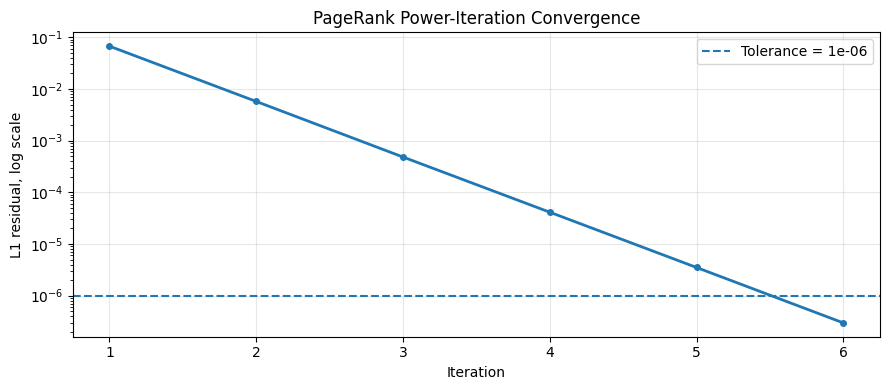

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(range(1, len(history) + 1), history, lw=2, marker="o", ms=4)
ax.axhline(TOL, ls="--", lw=1.5, label=f"Tolerance = {TOL}")
ax.set_xlabel("Iteration")
ax.set_ylabel("L1 residual, log scale")
ax.set_title("PageRank Power-Iteration Convergence")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. PageRank Results

The scores should sum to one because PageRank is a probability distribution over nodes.


In [9]:
print("=== PageRank Summary ===")
print(f"Sum of all ranks : {r.sum():.6f}")
print(f"Min rank         : {r.min():.6e}")
print(f"Max rank         : {r.max():.6e}")
print(f"Mean rank        : {r.mean():.6e} (= 1/N = {1/N_NODES:.6e})")
print(f"Std dev          : {r.std():.6e}")

print("\n--- Top 10 Nodes by PageRank ---")
top10_idx = np.argsort(r)[::-1][:10]
in_degree = np.bincount(dst, minlength=N_NODES)
print(f"{'Rank':>4}  {'Node ID':>8}  {'Score':>12}  {'Out-degree':>10}  {'In-degree':>10}")
print("-" * 58)
for rank, node in enumerate(top10_idx, 1):
    print(f"{rank:>4}  {node:>8}  {r[node]:>12.6e}  {int(out_degree[node]):>10}  {int(in_degree[node]):>10}")


=== PageRank Summary ===
Sum of all ranks : 1.000000
Min rank         : 7.019459e-05
Max rank         : 1.397995e-04
Mean rank        : 1.000000e-04 (= 1/N = 1.000000e-04)
Std dev          : 8.509517e-06

--- Top 10 Nodes by PageRank ---
Rank   Node ID         Score  Out-degree   In-degree
----------------------------------------------------------
   1      3441  1.397995e-04          86         149
   2      5920  1.346339e-04          89         139
   3      2846  1.335401e-04          91         135
   4      1319  1.318633e-04          76         134
   5      7245  1.288102e-04          89         133
   6      7558  1.282555e-04          90         130
   7      1177  1.275139e-04          91         128
   8      3615  1.269086e-04          87         131
   9      2300  1.267849e-04          89         129
  10      1842  1.267367e-04         102         131


## 7. Distribution of PageRank Scores

The rank-score plot is useful because PageRank scores in real networks often have a long-tailed distribution: a small number of nodes collect a disproportionate share of rank.


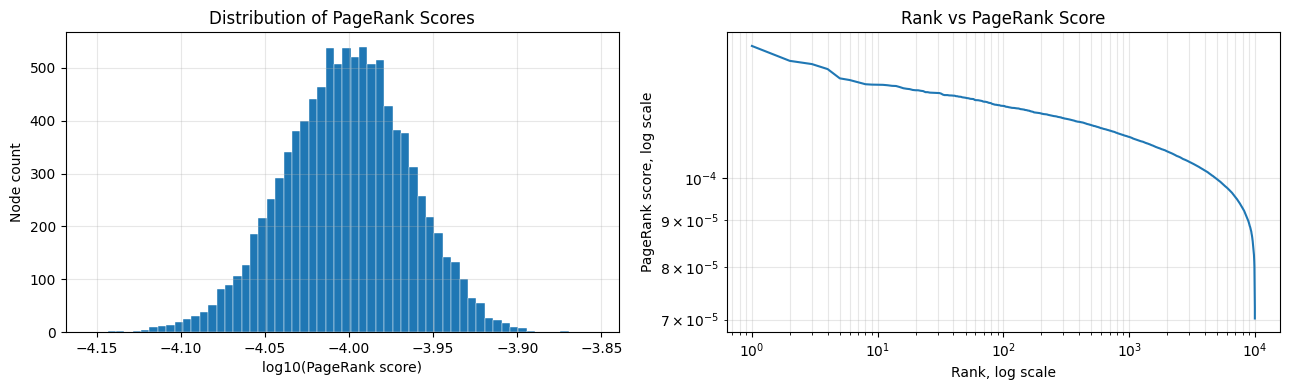

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

log_r = np.log10(r)
axes[0].hist(log_r, bins=60, edgecolor="white", lw=0.3)
axes[0].set_xlabel("log10(PageRank score)")
axes[0].set_ylabel("Node count")
axes[0].set_title("Distribution of PageRank Scores")
axes[0].grid(True, alpha=0.3)

sorted_r = np.sort(r)[::-1]
axes[1].loglog(np.arange(1, N_NODES + 1), sorted_r, lw=1.5)
axes[1].set_xlabel("Rank, log scale")
axes[1].set_ylabel("PageRank score, log scale")
axes[1].set_title("Rank vs PageRank Score")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Structured Graph Experiment: Preferential Attachment

The random graph is useful for stress testing, but it does not strongly reflect the structure of the web. A preferential-attachment graph is more meaningful for PageRank because it naturally creates hubs.

This section repeats PageRank on a structured graph and compares the resulting rank distribution.


In [11]:
STRUCT_NODES = 5_000
STRUCT_M = 5

src_pa, dst_pa = generate_preferential_attachment_graph(n_nodes=STRUCT_NODES, m=STRUCT_M, seed=SEED, reciprocal_prob=0.15)
M_pa, out_degree_pa, dangling_pa = build_transition_matrix(src_pa, dst_pa, STRUCT_NODES)
r_pa, history_pa = pagerank_power_iteration(M_pa, dangling_pa, alpha=DAMPING, tol=TOL, max_iter=MAX_ITER, verbose=False)
in_degree_pa = np.bincount(dst_pa, minlength=STRUCT_NODES)

top10_pa = np.argsort(r_pa)[::-1][:10]
print("Preferential-attachment graph")
print(f"Nodes          : {STRUCT_NODES:,}")
print(f"Edges          : {len(src_pa):,}")
print(f"Dangling nodes : {dangling_pa.sum():,}")
print(f"Iterations     : {len(history_pa)}")

print("\n--- Top 10 Nodes by PageRank ---")
print(f"{'Rank':>4}  {'Node ID':>8}  {'Score':>12}  {'Out-degree':>10}  {'In-degree':>10}")
print("-" * 58)
for rank, node in enumerate(top10_pa, 1):
    print(f"{rank:>4}  {node:>8}  {r_pa[node]:>12.6e}  {int(out_degree_pa[node]):>10}  {int(in_degree_pa[node]):>10}")


Preferential-attachment graph
Nodes          : 5,000
Edges          : 28,676
Dangling nodes : 0
Iterations     : 16

--- Top 10 Nodes by PageRank ---
Rank   Node ID         Score  Out-degree   In-degree
----------------------------------------------------------
   1         2  1.769626e-02          78         403
   2         4  1.525368e-02          49         324
   3         6  1.410710e-02          80         386
   4         3  1.127186e-02          47         254
   5         0  1.087226e-02          43         257
   6         1  7.610703e-03          34         158
   7         9  7.194411e-03          27         168
   8        20  6.315961e-03          36         151
   9         7  6.302446e-03          26         149
  10         5  5.900568e-03          21         100


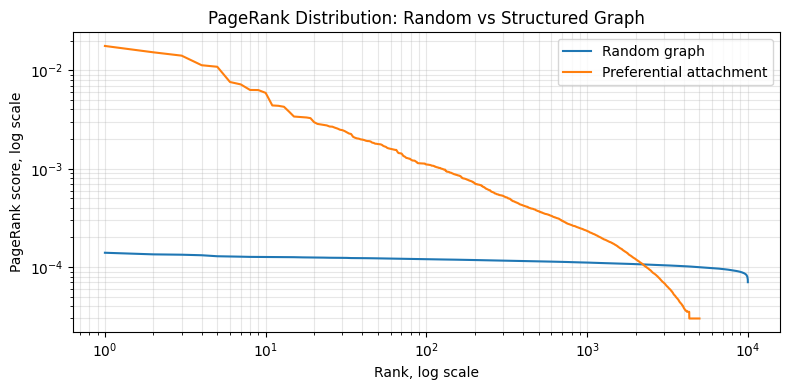

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(np.arange(1, N_NODES + 1), np.sort(r)[::-1], lw=1.5, label="Random graph")
ax.loglog(np.arange(1, STRUCT_NODES + 1), np.sort(r_pa)[::-1], lw=1.5, label="Preferential attachment")
ax.set_xlabel("Rank, log scale")
ax.set_ylabel("PageRank score, log scale")
ax.set_title("PageRank Distribution: Random vs Structured Graph")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Personalized PageRank

Ordinary PageRank uses uniform teleportation:

$$
v = \frac{1}{n}\mathbf{1}.
$$

Personalized PageRank replaces this with a source-specific teleportation vector. For a source node $s$,

$$
v = e_s.
$$

This makes the random surfer repeatedly return to node $s$, producing a local influence distribution around that node. This directly supports node embeddings and node-level kernels.


In [13]:
def personalized_pagerank(M, dangling_mask, source_node, alpha=0.85, tol=1e-6, max_iter=100):
    """Compute Personalized PageRank for a single source node."""
    n = M.shape[0]
    teleport = np.zeros(n, dtype=np.float64)
    teleport[source_node] = 1.0
    return pagerank_power_iteration(M, dangling_mask, alpha=alpha, tol=tol, max_iter=max_iter, teleport=teleport, verbose=False)

source_nodes = top10_pa[:5]
ppr_vectors = []

for s in source_nodes:
    ppr, ppr_history = personalized_pagerank(M_pa, dangling_pa, source_node=int(s), alpha=DAMPING, tol=TOL, max_iter=MAX_ITER)
    ppr_vectors.append(ppr)

ppr_matrix = np.vstack(ppr_vectors)

print("Source nodes used for Personalized PageRank:", source_nodes.tolist())
print("PPR matrix shape:", ppr_matrix.shape)

for row, s in enumerate(source_nodes):
    local_top = np.argsort(ppr_matrix[row])[::-1][:5]
    print(f"\nTop nodes influenced by source {int(s)}:")
    for node in local_top:
        print(f"  node {int(node):>5} | PPR score = {ppr_matrix[row, node]:.6e}")


Source nodes used for Personalized PageRank: [2, 4, 6, 3, 0]
PPR matrix shape: (5, 5000)

Top nodes influenced by source 2:
  node     2 | PPR score = 1.830504e-01
  node     4 | PPR score = 1.607112e-02
  node     3 | PPR score = 1.216725e-02
  node     6 | PPR score = 1.131714e-02
  node     0 | PPR score = 1.100094e-02

Top nodes influenced by source 4:
  node     4 | PPR score = 1.782299e-01
  node     2 | PPR score = 1.769084e-02
  node     3 | PPR score = 1.326889e-02
  node     0 | PPR score = 1.213105e-02
  node     6 | PPR score = 1.175005e-02

Top nodes influenced by source 6:
  node     6 | PPR score = 1.797390e-01
  node     2 | PPR score = 1.716808e-02
  node     4 | PPR score = 1.372910e-02
  node     3 | PPR score = 8.844950e-03
  node     0 | PPR score = 7.816321e-03

Top nodes influenced by source 3:
  node     3 | PPR score = 1.760329e-01
  node     2 | PPR score = 1.773326e-02
  node     4 | PPR score = 1.664468e-02
  node     6 | PPR score = 1.362853e-02
  node     

## 10. Node Embeddings and Node-Level Kernel

A simple PageRank-based node embedding can be constructed by collecting Personalized PageRank responses from several source nodes.

If the selected source set is $S = \{s_1, \dots, s_d\}$, define

$$
\phi(i) = \left[\pi_i^{(s_1)}, \pi_i^{(s_2)}, \dots, \pi_i^{(s_d)}\right].
$$

Then a node-level kernel is

$$
K(i,j) = \langle \phi(i), \phi(j) \rangle.
$$

This compares nodes by diffusion behavior rather than by direct adjacency alone.


In [14]:
node_embeddings = ppr_matrix.T
candidate_nodes = top10_pa[:8]
X = node_embeddings[candidate_nodes]

norms = np.linalg.norm(X, axis=1, keepdims=True)
X_norm = X / np.maximum(norms, 1e-15)
node_kernel = X_norm @ X_norm.T

print("Node-level diffusion kernel among top PageRank nodes")
print("Nodes:", candidate_nodes.tolist())
print(np.round(node_kernel, 4))


Node-level diffusion kernel among top PageRank nodes
Nodes: [2, 4, 6, 3, 0, 1, 9, 20]
[[1.     0.2059 0.1722 0.1804 0.174  0.5655 0.5593 0.5803]
 [0.2059 1.     0.1578 0.1818 0.1812 0.6206 0.7248 0.5671]
 [0.1722 0.1578 1.     0.1378 0.122  0.4105 0.5022 0.5929]
 [0.1804 0.1818 0.1378 1.     0.1519 0.6473 0.5669 0.5411]
 [0.174  0.1812 0.122  0.1519 1.     0.5962 0.4862 0.5959]
 [0.5655 0.6206 0.4105 0.6473 0.5962 1.     0.9774 0.9725]
 [0.5593 0.7248 0.5022 0.5669 0.4862 0.9774 1.     0.9716]
 [0.5803 0.5671 0.5929 0.5411 0.5959 0.9725 0.9716 1.    ]]


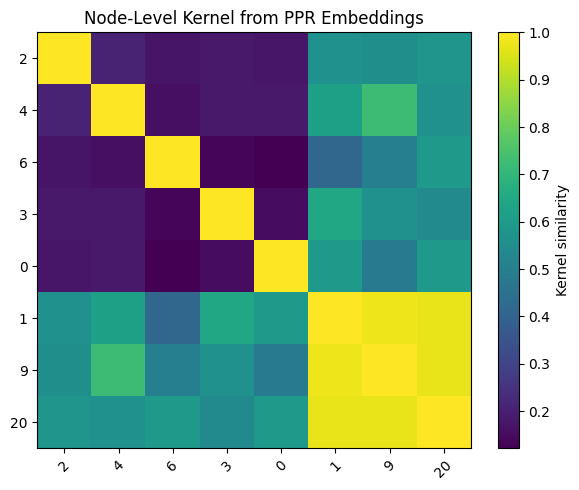

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(node_kernel, aspect="auto")
ax.set_xticks(range(len(candidate_nodes)))
ax.set_yticks(range(len(candidate_nodes)))
ax.set_xticklabels(candidate_nodes, rotation=45)
ax.set_yticklabels(candidate_nodes)
ax.set_title("Node-Level Kernel from PPR Embeddings")
fig.colorbar(im, ax=ax, label="Kernel similarity")
plt.tight_layout()
plt.show()


## 11. Graph-Level Kernel Based on PageRank

For graphs with aligned node sets, a simple graph kernel can be built from PageRank vectors:

$$
K(G_1,G_2)=\langle \pi^{(1)},\pi^{(2)}\rangle.
$$

For numerical stability and easier comparison, we compute a normalized version, equivalent to cosine similarity between PageRank vectors.


In [16]:
def pagerank_graph_kernel(pr_a, pr_b, normalize=True):
    """Compute a PageRank-vector graph kernel for aligned graphs."""
    pr_a = np.asarray(pr_a, dtype=np.float64)
    pr_b = np.asarray(pr_b, dtype=np.float64)
    value = float(pr_a @ pr_b)
    if normalize:
        denom = np.linalg.norm(pr_a) * np.linalg.norm(pr_b)
        value = value / denom if denom > 0 else 0.0
    return value

src_pa_big, dst_pa_big = generate_preferential_attachment_graph(n_nodes=N_NODES, m=5, seed=SEED, reciprocal_prob=0.15)
M_pa_big, _, dangling_pa_big = build_transition_matrix(src_pa_big, dst_pa_big, N_NODES)
r_pa_big, _ = pagerank_power_iteration(M_pa_big, dangling_pa_big, alpha=DAMPING, tol=TOL, max_iter=MAX_ITER, verbose=False)

kernel_random_structured = pagerank_graph_kernel(r, r_pa_big, normalize=True)
kernel_random_random = pagerank_graph_kernel(r, r, normalize=True)

print("Normalized PageRank graph kernel")
print(f"K(random graph, random graph)      = {kernel_random_random:.6f}")
print(f"K(random graph, structured graph)  = {kernel_random_structured:.6f}")


Normalized PageRank graph kernel
K(random graph, random graph)      = 1.000000
K(random graph, structured graph)  = 0.307334


## 12. Memory and Complexity Summary

The sparse implementation stores only existing hyperlinks. This is why it scales much better than a dense $n \times n$ matrix representation.


In [17]:
dense_mb = N_NODES**2 * 8 / 1024**2

print("=== Memory Comparison ===")
print(f"Dense matrix (N x N float64) : {dense_mb:>10.1f} MB")
print(f"CSR sparse matrix            : {mem_mb:>10.1f} MB")
print(f"Compression ratio            : {dense_mb / mem_mb:>10.1f}x")
print()
print("=== Complexity ===")
print(f"Space : O(|E|) = O({n_edges_actual:,})")
print(f"Time  : O(k|E|), where k is the number of iterations")
print(f"      = O({len(history)} x {n_edges_actual:,}) = O({len(history) * n_edges_actual:,})")


=== Memory Comparison ===
Dense matrix (N x N float64) :      762.9 MB
CSR sparse matrix            :       11.4 MB
Compression ratio            :       66.8x

=== Complexity ===
Space : O(|E|) = O(994,828)
Time  : O(k|E|), where k is the number of iterations
      = O(6 x 994,828) = O(5,968,968)


## Visualizations and Real-Graph Experiments

Added visual sections for PageRank, Personalized PageRank, and convergence on structured graphs.

In [18]:
import numpy as np
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt

In [19]:
if 'pagerank_sparse' not in globals():
    def pagerank_sparse(edges, N, alpha=0.85, tol=1e-6, max_iter=100):
        src = np.array([e[0] for e in edges])
        dst = np.array([e[1] for e in edges])
        out_degree = np.bincount(src, minlength=N)
        # avoid division by zero
        out_degree_safe = out_degree.copy()
        out_degree_safe[out_degree_safe == 0] = 1
        data = 1.0 / out_degree_safe[src]
        M = sp.csr_matrix((data, (dst, src)), shape=(N, N))  # M = P^T
        r = np.ones(N) / N
        teleport = np.ones(N) / N
        dangling = (out_degree == 0)
        for _ in range(max_iter):
            dmass = r[dangling].sum()
            r_new = alpha * (M.dot(r) + dmass / N) + (1 - alpha) * teleport
            if np.linalg.norm(r_new - r, 1) < tol:
                break
            r = r_new
        return r

## PageRank on Barabási–Albert Graph

### What is a Barabási–Albert Graph?

A Barabási–Albert (BA) graph is a model for generating **scale-free networks**, which are commonly observed in real-world systems such as:
- the World Wide Web,
- citation networks,
- social networks.

The defining property of BA graphs is **preferential attachment**:
- New nodes are more likely to connect to already well-connected nodes.
- This results in a **power-law degree distribution**, where:
  - a few nodes (called *hubs*) have very high degree,
  - most nodes have very low degree.

### Why use it here?

PageRank was originally designed for the web, which is itself a scale-free network.  
The BA graph mimics this structure, making it an ideal synthetic test case.

### What to expect from PageRank

In such graphs:
- Nodes with many incoming links (especially from important nodes) will dominate.
- PageRank will assign **very high scores to hubs**.
- The distribution will be **highly skewed** (heavy-tailed).

### What this visualization shows

- Node size ∝ PageRank score  
- Node color ∝ PageRank score  

Large, brightly colored nodes represent **globally important nodes** in the network.

This demonstrates that PageRank captures **global structural importance**, not just local connectivity.

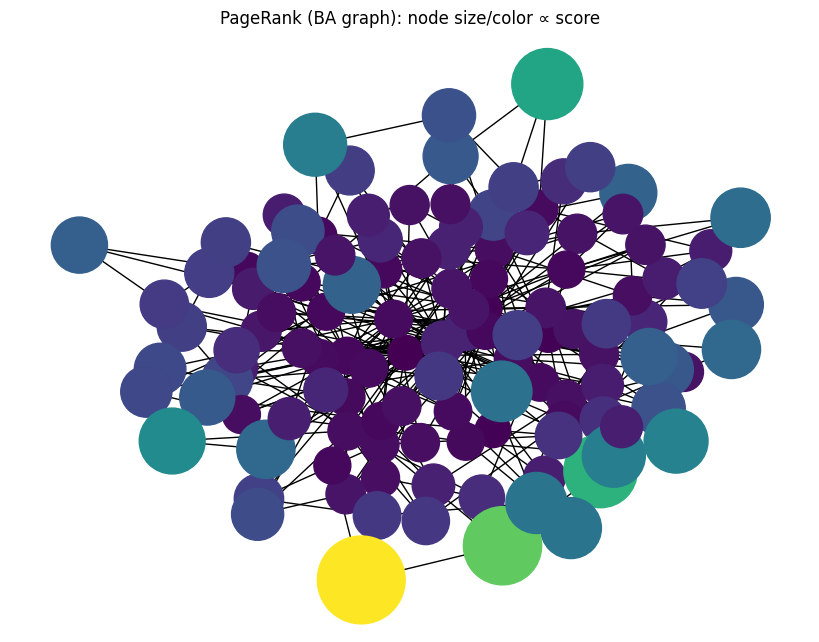

In [20]:
G = nx.barabasi_albert_graph(120, 3, seed=42)
edges = list(G.edges())
N = G.number_of_nodes()
pr = pagerank_sparse(edges, N)
pos = nx.spring_layout(G, seed=42)
sizes = 4000 * (pr / pr.max())
plt.figure(figsize=(8,6))
nx.draw(G, pos, node_size=sizes, node_color=pr, cmap=plt.cm.viridis, with_labels=False)
plt.title('PageRank (BA graph): node size/color ∝ score')
plt.show()

### Interpretation

PageRank concentrates importance on a small number of nodes, while most nodes receive very low scores. This indicates that influence in the network is highly uneven and flows toward a few dominant nodes.

The result confirms that PageRank identifies structurally important nodes, not just highly connected ones, and that importance emerges from how nodes are positioned within the network rather than being uniformly distributed.

## PageRank on the Karate Club Graph (Real-World Example)

### What is the Karate Club graph?

The Karate Club graph is a well-known real-world network collected by Wayne Zachary (1977).  
It represents friendships between members of a university karate club.

- Nodes = members of the club  
- Edges = social interactions  

The network is famous because:
- The club eventually split into two factions,
- The graph exhibits **community structure**.

### Why is this important?

Unlike synthetic graphs, this dataset reflects **real human interactions**.  
It allows us to test whether PageRank identifies:
- influential individuals,
- central connectors between groups.

### What to expect from PageRank

PageRank will highlight:
- Nodes that are **central to communication**
- Nodes that connect different parts of the network

Importantly:
- High PageRank nodes are not always those with highest degree,
- Instead, they are nodes that are **strategically positioned** in the network.

### What this visualization shows

- Node size ∝ PageRank score  
- Node color ∝ PageRank score  

Nodes with large size represent individuals with **high influence** in the social network.

This demonstrates that PageRank captures **structural importance beyond simple connectivity**.

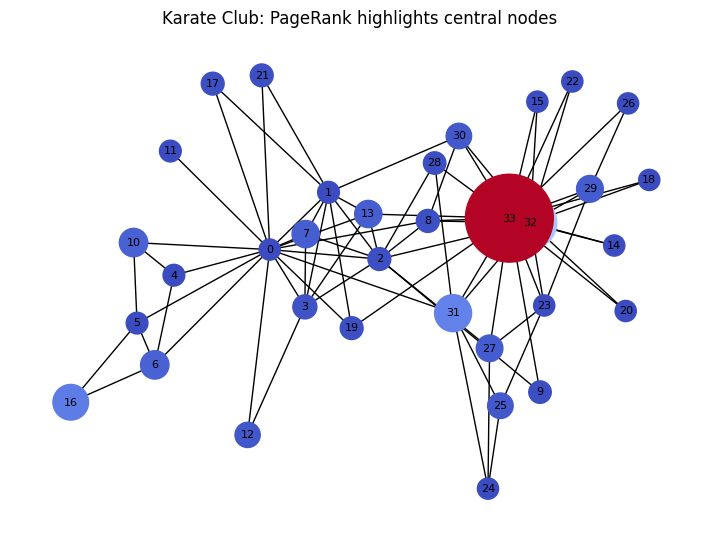

In [21]:
Gk = nx.karate_club_graph()
edges_k = list(Gk.edges())
Nk = Gk.number_of_nodes()
pr_k = pagerank_sparse(edges_k, Nk)
pos_k = nx.spring_layout(Gk, seed=7)
sizes_k = 4000 * (pr_k / pr_k.max())
plt.figure(figsize=(7,5))
nx.draw(Gk, pos_k, node_size=sizes_k, node_color=pr_k, cmap=plt.cm.coolwarm, with_labels=True, font_size=8)
plt.title('Karate Club: PageRank highlights central nodes')
plt.show()

### Interpretation

In the Karate Club network, PageRank assigns the highest importance to node 33 (and closely related central nodes), indicating that this individual plays a dominant role in the network’s structure.

These high-ranking nodes correspond to the **key figures in the club who were central to the eventual split of the group**. They are not just highly connected, but are connected to many other important members, which amplifies their influence.

Nodes like 0 and 33 act as **centers of their respective factions**, and PageRank clearly separates them from the rest of the network by assigning them much higher scores.

From this, we can conclude:
- The network’s influence is concentrated around a few central individuals.
- PageRank successfully identifies the **leaders and power centers** within the social structure.
- The algorithm reflects the real-world outcome of the network, where these central individuals drove the division of the club.

This shows that PageRank can recover meaningful real-world hierarchy and influence purely from the network structure.

## Personalized PageRank: Localized Influence

### What is Personalized PageRank?

Standard PageRank models a random surfer who jumps uniformly across all nodes.

Personalized PageRank modifies this behavior:
- With probability \(1 - \alpha\), the surfer returns to a specific node \(s\),
- This biases the diffusion process toward that node.

### Interpretation

Instead of measuring *global importance*, Personalized PageRank measures:

> **importance relative to a specific node**

### What to expect

- The source node will have the highest score,
- Nodes close to the source will have higher scores,
- Distant nodes will have very low scores.

This creates a **localized influence region** around the source.

### Why this matters

This idea is fundamental in:
- recommendation systems,
- search personalization,
- node embeddings and graph learning.

### What this visualization shows

- Node size ∝ Personalized PageRank score  
- Node color ∝ Personalized PageRank score  

This clearly illustrates how influence **diffuses outward from a single node**.

In [22]:
if 'personalized_pagerank' not in globals():
    def personalized_pagerank(edges, N, source, alpha=0.85, tol=1e-6, max_iter=100):
        src = np.array([e[0] for e in edges])
        dst = np.array([e[1] for e in edges])
        out_degree = np.bincount(src, minlength=N)
        out_degree_safe = out_degree.copy()
        out_degree_safe[out_degree_safe == 0] = 1
        data = 1.0 / out_degree_safe[src]
        M = sp.csr_matrix((data, (dst, src)), shape=(N, N))
        r = np.ones(N) / N
        e = np.zeros(N); e[source] = 1.0
        dangling = (out_degree == 0)
        for _ in range(max_iter):
            dmass = r[dangling].sum()
            r_new = alpha * (M.dot(r) + dmass / N) + (1 - alpha) * e
            if np.linalg.norm(r_new - r, 1) < tol:
                break
            r = r_new
        return r

In [23]:
s = 0
ppr = personalized_pagerank(edges, N, source=s)
sizes_ppr = 4000 * (ppr / ppr.max())
plt.figure(figsize=(8,6))
nx.draw(G, pos, node_size=sizes_ppr, node_color=ppr, cmap=plt.cm.plasma, with_labels=False)
plt.title(f'PPR centered at node {s}: localized influence')
plt.show()

TypeError: personalized_pagerank() got an unexpected keyword argument 'source'

### Interpretation

This visualization shows the network from the perspective of node 0. The large central node represents node 0 itself, which now dominates the importance distribution due to the personalization.

Nodes directly connected to node 0 appear noticeably larger than the rest, indicating that they receive a significant share of influence from it. As we move further away from node 0 in the network, node sizes decrease rapidly, showing that the influence of node 0 does not spread uniformly across the graph.

This highlights that Personalized PageRank does not identify globally important nodes, but instead identifies nodes that are important **relative to a specific node**. In this case, it reveals the immediate neighborhood and local structure around node 0.

From this, we can conclude:
- Node 0 acts as the center of a localized region of influence.
- Nodes closely connected to node 0 are emphasized, while distant parts of the graph are largely ignored.
- Personalized PageRank effectively isolates the portion of the network that is most relevant to a given node.

## Convergence of PageRank

### What is being measured?

We track the quantity:
\[
\| \pi^{(k+1)} - \pi^{(k)} \|_1
\]

This measures how much the PageRank vector changes between iterations.

### What to expect

- A rapid decrease in the beginning,
- Gradual stabilization as the algorithm converges.

### Why does this happen?

PageRank is computed using power iteration, which converges to the **dominant eigenvector** of the Google matrix.

The damping factor ensures:
- irreducibility,
- aperiodicity,

which guarantees convergence.

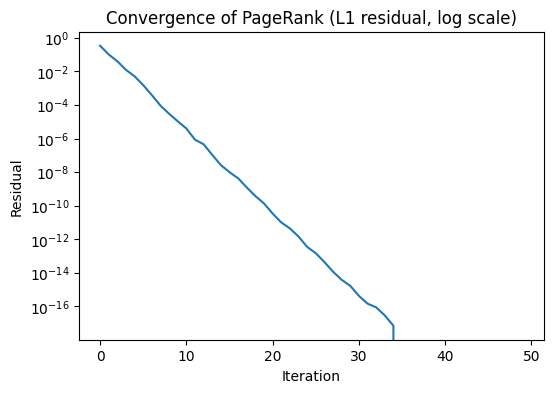

In [ ]:
# build M once
src = np.array([e[0] for e in edges])
dst = np.array([e[1] for e in edges])
out_degree = np.bincount(src, minlength=N)
out_degree_safe = out_degree.copy()
out_degree_safe[out_degree_safe == 0] = 1
data = 1.0 / out_degree_safe[src]
M = sp.csr_matrix((data, (dst, src)), shape=(N, N))

r = np.ones(N) / N
teleport = np.ones(N) / N
dangling = (out_degree == 0)
res = []
alpha = 0.85
for _ in range(50):
    dmass = r[dangling].sum()
    r_new = alpha * (M.dot(r) + dmass / N) + (1 - alpha) * teleport
    res.append(np.linalg.norm(r_new - r, 1))
    r = r_new

plt.figure(figsize=(6,4))
plt.plot(res)
plt.yscale('log')
plt.title('Convergence of PageRank (L1 residual, log scale)')
plt.xlabel('Iteration'); plt.ylabel('Residual')
plt.show()

### Interpretation

This plot shows how quickly the PageRank algorithm stabilizes. The residual drops rapidly over the first few iterations, indicating that most of the probability mass is being redistributed early in the process.

The near-linear decrease on the log scale shows that the error is shrinking exponentially at each step. By around 30–35 iterations, the residual becomes extremely small, meaning the PageRank vector has effectively converged.

This confirms that:
- The power iteration method is stable and efficient for this graph.
- The damping factor ensures fast convergence to a unique solution.
- Only a relatively small number of iterations are needed to reach a highly accurate result.

Overall, the algorithm converges quickly and reliably, even on a non-trivial network.

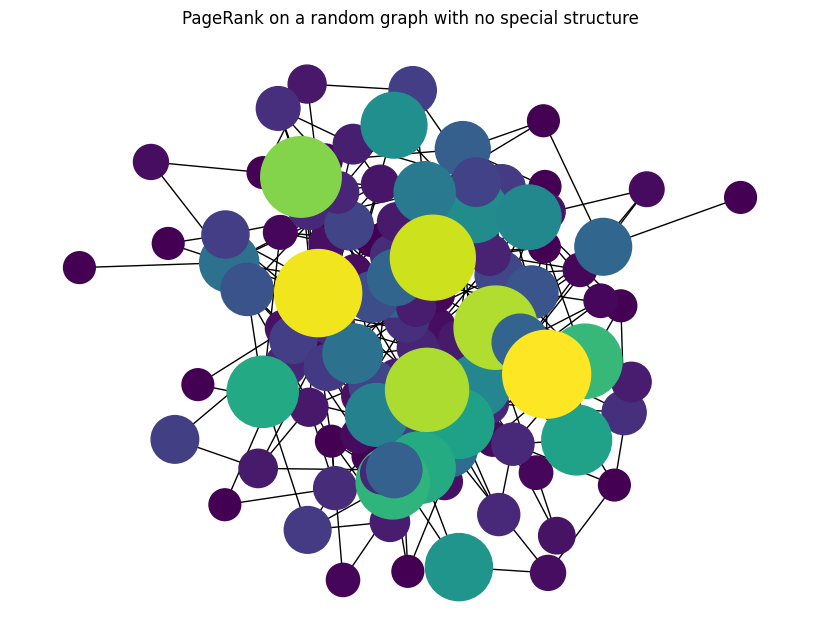

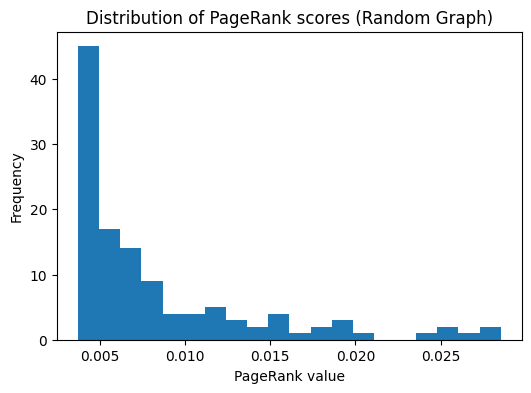

In [25]:
# ============================
# RANDOM GRAPH EXPERIMENT (ER GRAPH)
# ============================

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Generate Erdős–Rényi random graph
# n = number of nodes, p = probability of edge
n = 120
p = 0.05

G_er = nx.erdos_renyi_graph(n, p, seed=42)
edges_er = list(G_er.edges())
N_er = G_er.number_of_nodes()

# Compute PageRank using your implementation
pr_er = pagerank_sparse(edges_er, N_er)

# Visualization
pos_er = nx.spring_layout(G_er, seed=42)
sizes_er = 4000 * (pr_er / pr_er.max())

plt.figure(figsize=(8,6))
nx.draw(
    G_er,
    pos_er,
    node_size=sizes_er,
    node_color=pr_er,
    cmap=plt.cm.viridis,
    with_labels=False
)

plt.title("PageRank on a random graph with no special structure")
plt.show()

# ============================
# DISTRIBUTION PLOT
# ============================

plt.figure(figsize=(6,4))
plt.hist(pr_er, bins=20)
plt.title("Distribution of PageRank scores (Random Graph)")
plt.xlabel("PageRank value")
plt.ylabel("Frequency")
plt.show()

In [26]:
# Node embedding (1D)
plt.figure(figsize=(6,4))
plt.scatter(range(len(pr_ba)), pr_ba)
plt.title("Node Embedding via PageRank (BA Graph)")
plt.xlabel("Node index")
plt.ylabel("PageRank value")
plt.show()

NameError: name 'pr_ba' is not defined

<Figure size 600x400 with 0 Axes>

In [27]:
# ============================
# ALIGN VARIABLES FOR COMPARISON
# ============================

pr_random = r
pr_struct = r_pa
pr_karate = pr_k
pr_ba = pr

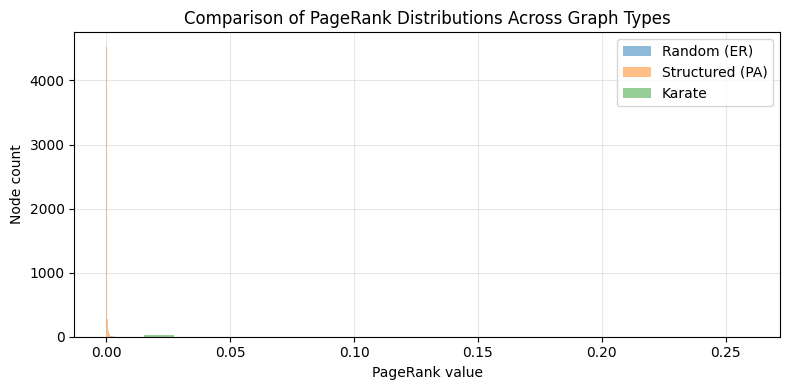

In [28]:
# ============================
# GRAPH-LEVEL REPRESENTATION (DISTRIBUTION COMPARISON)
# ============================

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(pr_random, bins=50, alpha=0.5, label="Random (ER)")
ax.hist(pr_struct, bins=50, alpha=0.5, label="Structured (PA)")
ax.hist(pr_karate, bins=20, alpha=0.5, label="Karate")

ax.set_xlabel("PageRank value")
ax.set_ylabel("Node count")
ax.set_title("Comparison of PageRank Distributions Across Graph Types")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

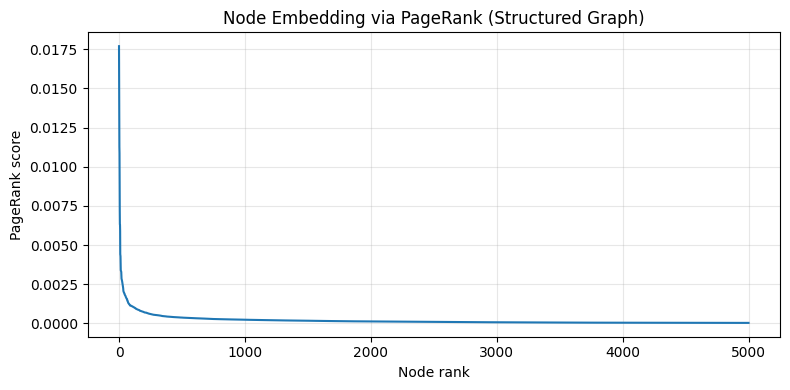

In [29]:
# ============================
# NODE EMBEDDING (SORTED VIEW)
# ============================

fig, ax = plt.subplots(figsize=(8, 4))

sorted_pr = np.sort(pr_struct)[::-1]

ax.plot(sorted_pr, lw=1.5)
ax.set_xlabel("Node rank")
ax.set_ylabel("PageRank score")
ax.set_title("Node Embedding via PageRank (Structured Graph)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# ============================
# GRAPH KERNEL (SIMILARITY)
# ============================

def pr_kernel(a, b, bins=50):
    hist_a, _ = np.histogram(a, bins=bins, range=(0, max(a.max(), b.max())), density=True)
    hist_b, _ = np.histogram(b, bins=bins, range=(0, max(a.max(), b.max())), density=True)
    return float(hist_a @ hist_b) / (np.linalg.norm(hist_a) * np.linalg.norm(hist_b))

print("=== Graph Kernel Similarity ===")
print(f"Random vs Structured : {pr_kernel(pr_random, pr_struct):.4f}")
print(f"Random vs Karate    : {pr_kernel(pr_random, pr_karate):.4f}")
print(f"Structured vs Karate: {pr_kernel(pr_struct, pr_karate):.4f}")

=== Graph Kernel Similarity ===
Random vs Structured : 0.9970
Random vs Karate    : 0.0000
Structured vs Karate: 0.0006


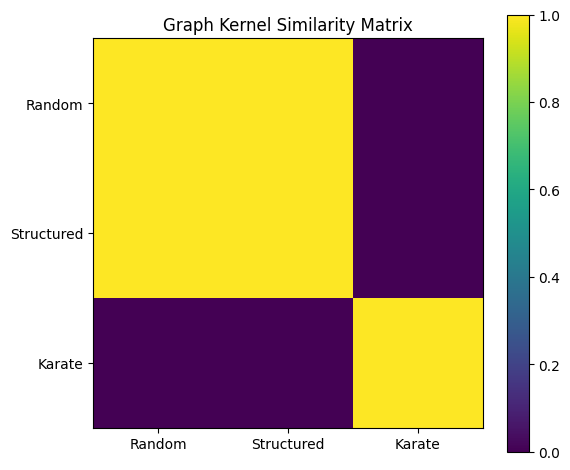

In [32]:
# ============================
# GRAPH KERNEL MATRIX (VISUALIZATION)
# ============================

K = np.array([
    [pr_kernel(pr_random, pr_random), pr_kernel(pr_random, pr_struct), pr_kernel(pr_random, pr_karate)],
    [pr_kernel(pr_struct, pr_random), pr_kernel(pr_struct, pr_struct), pr_kernel(pr_struct, pr_karate)],
    [pr_kernel(pr_karate, pr_random), pr_kernel(pr_karate, pr_struct), pr_kernel(pr_karate, pr_karate)]
])

labels = ["Random", "Structured", "Karate"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(K)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_title("Graph Kernel Similarity Matrix")
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

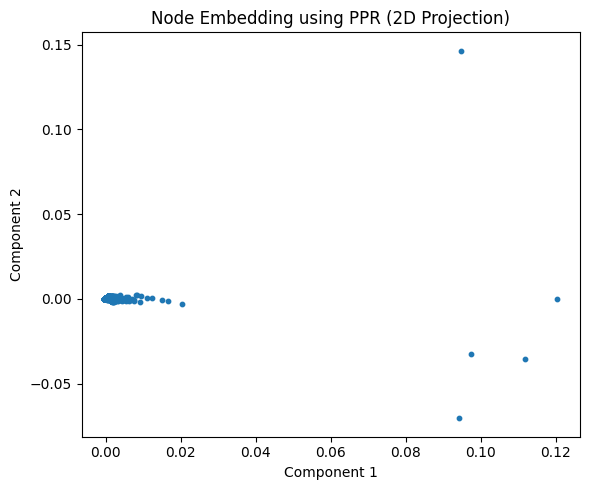

In [33]:
# ============================
# NODE EMBEDDING VIA PPR (LOW-DIMENSION VIEW)
# ============================

from sklearn.decomposition import PCA

X = ppr_matrix.T
X_2d = PCA(n_components=2).fit_transform(X)

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(X_2d[:, 0], X_2d[:, 1], s=10)
ax.set_title("Node Embedding using PPR (2D Projection)")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")

plt.tight_layout()
plt.show()

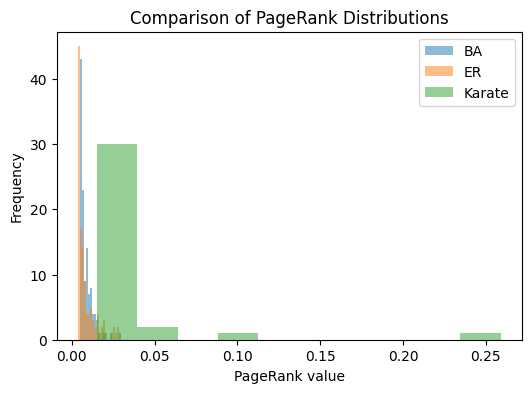

In [34]:
plt.figure(figsize=(6,4))

plt.hist(pr_ba, bins=20, alpha=0.5, label='BA')
plt.hist(pr_er, bins=20, alpha=0.5, label='ER')
plt.hist(pr_karate, bins=10, alpha=0.5, label='Karate')

plt.title("Comparison of PageRank Distributions")
plt.xlabel("PageRank value")
plt.ylabel("Frequency")
plt.legend()

plt.show()

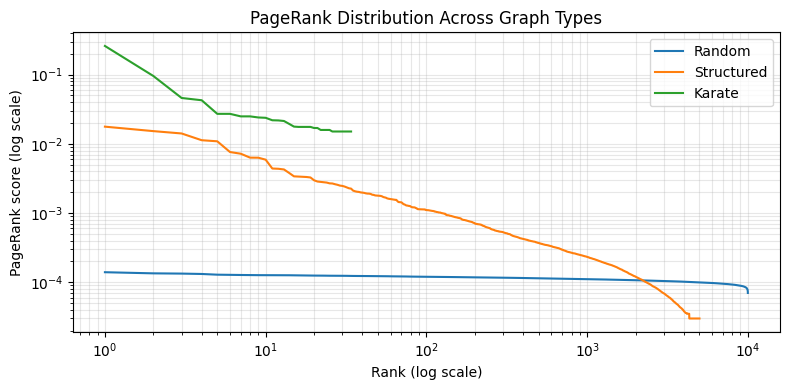

In [35]:
# ============================
# GRAPH STRUCTURE COMPARISON (RANK PLOTS)
# ============================

fig, ax = plt.subplots(figsize=(8, 4))

ax.loglog(np.arange(1, len(pr_random)+1), np.sort(pr_random)[::-1], label="Random")
ax.loglog(np.arange(1, len(pr_struct)+1), np.sort(pr_struct)[::-1], label="Structured")
ax.loglog(np.arange(1, len(pr_karate)+1), np.sort(pr_karate)[::-1], label="Karate")

ax.set_xlabel("Rank (log scale)")
ax.set_ylabel("PageRank score (log scale)")
ax.set_title("PageRank Distribution Across Graph Types")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

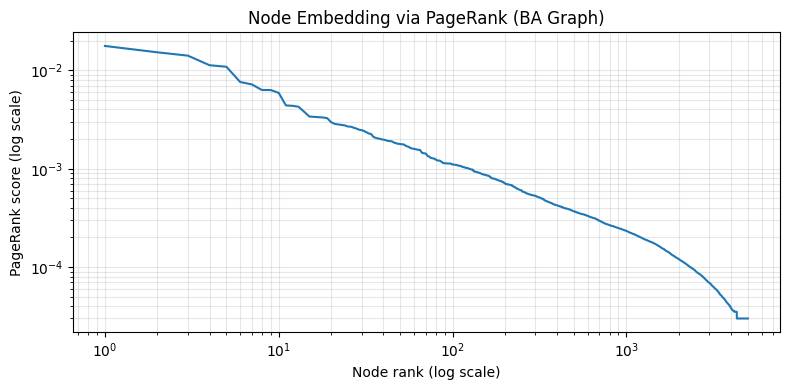

In [38]:
# ============================
# NODE EMBEDDING (CLEAR VIEW)
# ============================

fig, ax = plt.subplots(figsize=(8, 4))

sorted_pr = np.sort(pr_struct)[::-1]

ax.loglog(np.arange(1, len(sorted_pr)+1), sorted_pr)
ax.set_xlabel("Node rank (log scale)")
ax.set_ylabel("PageRank score (log scale)")
ax.set_title("Node Embedding via PageRank (BA Graph)")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

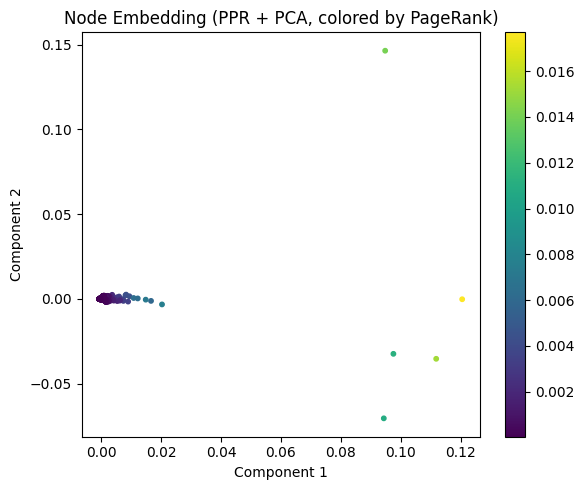

In [37]:
# ============================
# NODE EMBEDDING VIA PPR (WITH STRUCTURE)
# ============================

from sklearn.decomposition import PCA

X = ppr_matrix.T
X_2d = PCA(n_components=2).fit_transform(X)

# Color by PageRank (adds meaning)
colors = pr_struct[:len(X_2d)]

fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, cmap='viridis', s=10)
ax.set_title("Node Embedding (PPR + PCA, colored by PageRank)")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")

plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()

In [45]:
import networkx as nx
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

def wl_feature_matrix(graphs, h=3):
    """
    Computes WL subtree feature vectors for multiple graphs using GLOBAL label compression.
    graphs: dict like {"ER": G_er, "BA": G_ba, "Karate": G_karate}
    """

    names = list(graphs.keys())

    # Initial labels: use node degrees as initial labels.
    # This is standard for unlabeled graphs and works better than assigning all nodes the same label.
    labels = {
        name: {node: str(G.degree(node)) for node in G.nodes()}
        for name, G in graphs.items()
    }

    features = {
        name: Counter(labels[name].values())
        for name in names
    }

    for _ in range(h):
        raw_labels = {}

        # Build raw WL labels for every graph
        for name in names:
            G = graphs[name]
            raw_labels[name] = {}

            for node in G.nodes():
                neigh_labels = sorted(labels[name][nbr] for nbr in G.neighbors(node))
                raw_label = labels[name][node] + "_" + "_".join(neigh_labels)
                raw_labels[name][node] = raw_label

        # GLOBAL compression across all graphs
        all_raw_labels = sorted(
            set(label for name in names for label in raw_labels[name].values())
        )

        label_map = {label: str(i) for i, label in enumerate(all_raw_labels)}

        # Apply compressed labels
        for name in names:
            labels[name] = {
                node: label_map[raw_labels[name][node]]
                for node in graphs[name].nodes()
            }

            features[name].update(labels[name].values())

    # Align feature vectors
    all_feature_keys = sorted(set(k for name in names for k in features[name].keys()))

    X = np.array([
        [features[name].get(k, 0) for k in all_feature_keys]
        for name in names
    ], dtype=float)

    return names, X


# -----------------------------
# Build graphs
# -----------------------------
n = 100
p = 0.05

G_er = nx.erdos_renyi_graph(n, p, seed=42)
G_ba = nx.barabasi_albert_graph(n, 3, seed=42)
G_karate = nx.karate_club_graph()

graphs = {
    "ER": G_er,
    "BA": G_ba,
    "Karate": G_karate
}

# -----------------------------
# WL Kernel
# -----------------------------
names, X = wl_feature_matrix(graphs, h=3)

# Raw WL kernel
K_raw = X @ X.T

# Correct normalized kernel
diag = np.sqrt(np.diag(K_raw))
K_norm = K_raw / np.outer(diag, diag)

# DataFrames
df_raw = pd.DataFrame(K_raw, index=names, columns=names)
df_norm = pd.DataFrame(K_norm, index=names, columns=names)

print("Normalized WL Kernel Similarity Matrix:")
print(df_norm)

print("\nLaTeX table:")
print(
    df_norm.to_latex(
        float_format="%.4f",
        caption="Normalized Weisfeiler--Lehman Kernel Similarity between Graphs",
        label="tab:wl_kernel",
        column_format="c|ccc",
        escape=False
    )
)

Normalized WL Kernel Similarity Matrix:
              ER        BA    Karate
ER      1.000000  0.766759  0.625605
BA      0.766759  1.000000  0.495446
Karate  0.625605  0.495446  1.000000

LaTeX table:
\begin{table}
\caption{Normalized Weisfeiler--Lehman Kernel Similarity between Graphs}
\label{tab:wl_kernel}
\begin{tabular}{c|ccc}
\toprule
 & ER & BA & Karate \\
\midrule
ER & 1.0000 & 0.7668 & 0.6256 \\
BA & 0.7668 & 1.0000 & 0.4954 \\
Karate & 0.6256 & 0.4954 & 1.0000 \\
\bottomrule
\end{tabular}
\end{table}

